In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [3]:
%%time
f_anndata_in = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_dev_v1/DevVIS_multiome_snRNA_processed_sst_adult.h5ad'
adata_hvg = sc.read(f_anndata_in)
adata_hvg

CPU times: user 62.7 ms, sys: 248 ms, total: 311 ms
Wall time: 1.43 s


AnnData object with n_obs × n_vars = 1149 × 4880
    obs: 'Unnamed: 0', 'subcluster_id', 'subcluster_label', 'cluster_label', 'subclass_label', 'class_label', 'subcluster_prob', 'cluster_probability', 'subclass_probability', 'class_probability', 'library_prep', 'roi', 'sex', 'donor_name', 'age_label', 'cellNames'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [4]:
genes_hvg = adata_hvg.var.index.values

# Need to remove PC1!!!

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [5]:
from sklearn.decomposition import PCA

In [6]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.cluster_label.cat.codes
norm_mat = np.array(adata_hvg.layers['lognorm'])
sca = SCA(norm_mat, types)

In [7]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(1149, 4880, (1149, 4880))

In [8]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

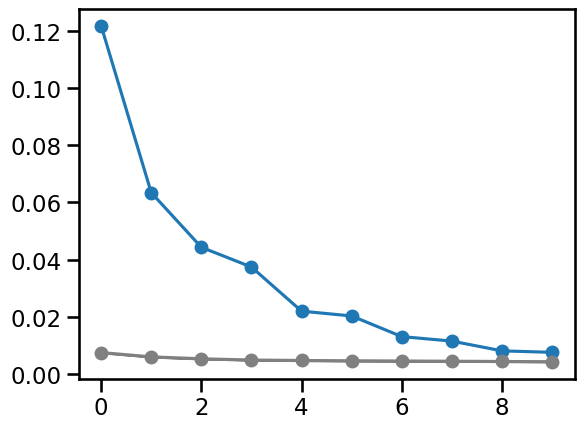

In [9]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

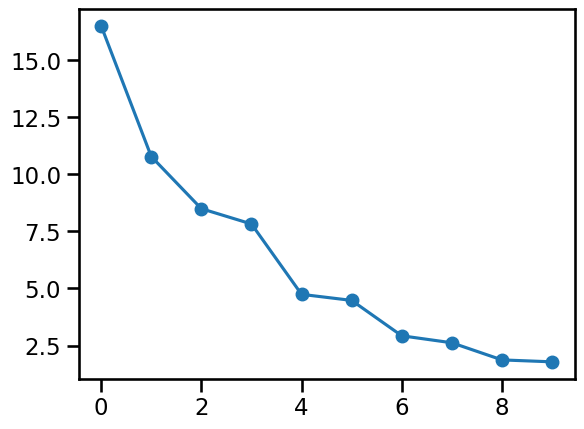

In [10]:
plt.plot(pca.explained_variance_ratio_/avg, '-o')

In [11]:
noc  = 3 
ndim = noc-1
nrepeats = 3

In [13]:
# data 
skip_pc1 = True
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1) #skip_pc1)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use data


In [14]:
# gshuff
sca.setup_feature_matrix(method='gshuff')
xp_gshuff, aa_gshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_gshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use shuffled data


In [15]:
# tshuff 
sca.setup_feature_matrix(method='tshuff')
xp_tshuff, aa_tshuff, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1)
aa_tshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats, skip_pc1=skip_pc1)

use per-type shuffled data


## plot

In [16]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

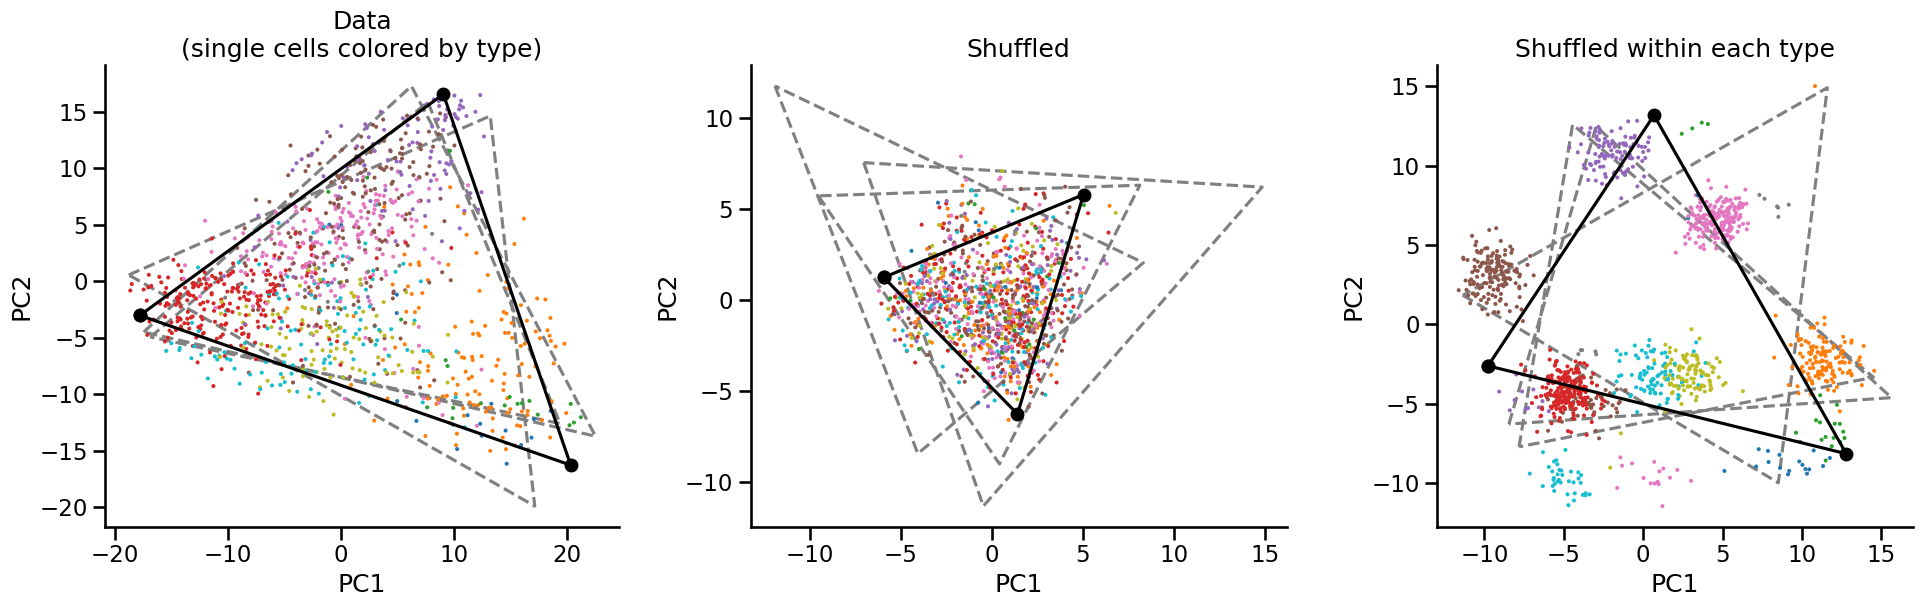

In [17]:
# plot
fig, axs = plt.subplots(1,3,figsize=(8*3,6))
ax = axs[0]
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax = axs[1]
ax.set_title('Shuffled')
ax.scatter(xp_gshuff[:,0], xp_gshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_gshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_gshuff_boots[i], fmt='--', color='gray', zorder=0)

ax = axs[2]
ax.set_title('Shuffled within each type')
ax.scatter(xp_tshuff[:,0], xp_tshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_tshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_tshuff_boots[i], fmt='--', color='gray', zorder=0)

for i in range(3):
    ax = axs[i]
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.grid(False)
    
plt.show()

In [18]:
adata_hvg.obs.cluster_label

AAAGCACCATCATGTG-L8XR_220331_02_A11-1170314855     758_Sst Gaba_1
AACAGATAGGACACTT-L8XR_220331_02_A11-1170314855     792_Sst Gaba_7
AACCCGCAGGTGTTAC-L8XR_220331_02_A11-1170314855    811_Sst Gaba_13
AACTACTCATCGCTCC-L8XR_220331_02_A11-1170314855    803_Sst Gaba_10
AACTAGTGTAACCAGC-L8XR_220331_02_A11-1170314855    803_Sst Gaba_10
                                                       ...       
TTGTTCCCAGTAAAGC-L8XR_220721_02_D06-1196254077    803_Sst Gaba_10
TTTAACCTCACTAATG-L8XR_220721_02_D06-1196254077     758_Sst Gaba_1
TTTCCGGGTGAGCACT-L8XR_220721_02_D06-1196254077    803_Sst Gaba_10
TTTGTCTAGTATTGCA-L8XR_220721_02_D06-1196254077     795_Sst Gaba_8
TTTGTGGCACAATGCC-L8XR_220721_02_D06-1196254077     758_Sst Gaba_1
Name: cluster_label, Length: 1149, dtype: category
Categories (20, object): ['757_Sst Gaba_1', '758_Sst Gaba_1', '761_Sst Gaba_1', '777_Sst Gaba_4', ..., '814_Sst Gaba_14', '818_Sst Gaba_16', '819_Sst Gaba_16', '820_Sst Gaba_16']

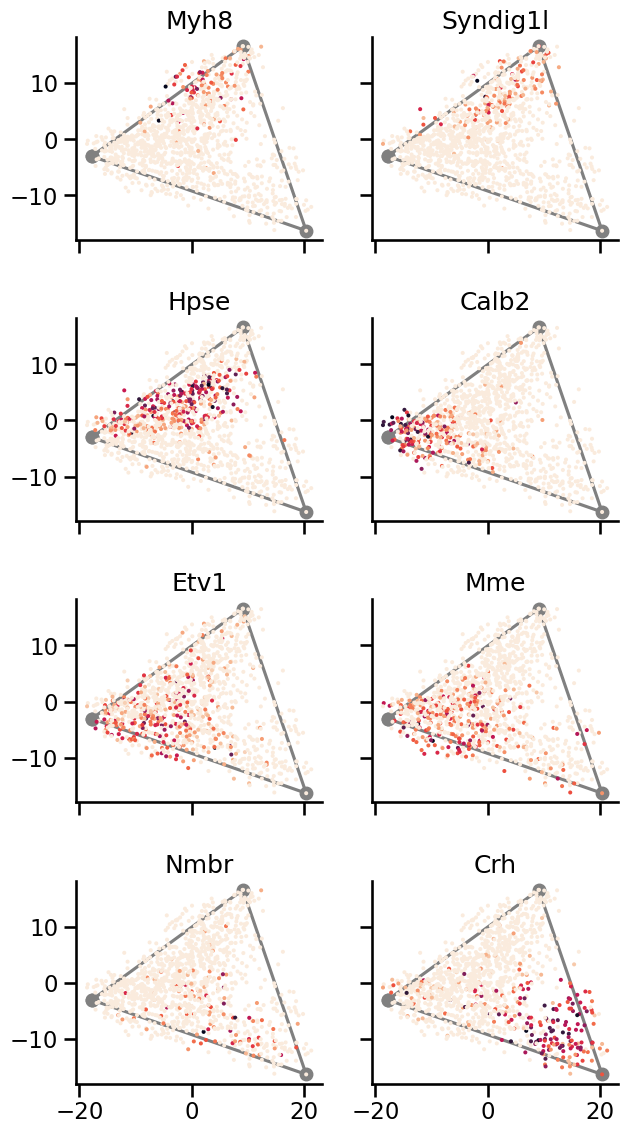

In [40]:
gns = [
    'Myh8', 'Syndig1l', 
    'Hpse', 
    'Calb2', 'Etv1',   
    'Mme',
    'Nmbr', 
    'Crh', 
]
n = len(gns)
nx = 2
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny,nx,figsize=(3.5*nx,3.5*ny), sharex=True, sharey=True)
for i, gn in enumerate(gns):
    ax = axs.flat[i]
    gexp = np.array(adata_hvg[:,gn].layers['lognorm']).reshape(-1,)
    g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
    plot_archetype(ax, aa, fmt='-o', color='gray', zorder=0)
    # fig.colorbar(g, shrink=0.2, aspect=5)
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.set_title(gn)

# for i in range(nrepeats):
#     plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)

In [48]:
# data 
skip_pc1 = True
ndim = 3
noc = 4

sca.setup_feature_matrix(method='data')
xp2, aa2, _ = sca.proj_and_pcha(ndim, noc, skip_pc1=skip_pc1) #skip_pc1)

use data


In [74]:
aa2

array([[-15.48648978,  -1.89494088,   9.5919199 ,  20.32997701],
       [ -4.98144456,   6.565784  ,  14.86512493, -16.29203315],
       [  3.1677033 , -14.06241366,  11.79539661,   2.0597828 ]])

In [62]:
df = np.array(adata_hvg[:,gns].layers['lognorm']) # .reshape(-1,)
df = pd.DataFrame(df, columns=gns)
df['x'] = xp2[:,0]
df['y'] = xp2[:,1]
df['z'] = xp2[:,2]
df['cluster'] = adata_hvg.obs['cluster_label'].values
df

,Myh8,Syndig1l,Hpse,Calb2,Etv1,Mme,Nmbr,Crh,x,y,z,cluster
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,2.365182,12.163015,-10.958887,-0.830133,758_Sst Gaba_1
1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-5.251124,3.235272,-3.188053,792_Sst Gaba_7
2,0.0,0.0,0.000000,0.000000,2.637708,0.000000,0.0,0.000000,6.759924,-7.890802,3.066940,811_Sst Gaba_13
3,0.0,0.0,0.000000,1.223658,0.000000,0.000000,0.0,0.000000,-8.616940,-4.623893,5.249563,803_Sst Gaba_10
4,0.0,0.0,0.000000,0.000000,0.000000,1.153507,0.0,0.000000,-5.579725,-0.332545,-0.748708,803_Sst Gaba_10
...,...,...,...,...,...,...,...,...,...,...,...,...
1144,0.0,0.0,0.459338,0.000000,0.000000,0.459338,0.0,0.000000,-4.964238,-0.764631,1.662526,803_Sst Gaba_10
1145,0.0,0.0,0.000000,0.000000,0.000000,0.460566,0.0,0.000000,19.771570,-5.544478,-2.897904,758_Sst Gaba_1
1146,0.0,0.0,0.000000,0.000000,0.701586,0.000000,0.0,0.000000,-5.445870,-3.245605,3.628792,803_Sst Gaba_10
1147,0.0,0.0,0.000000,0.000000,0.715375,0.000000,0.0,0.000000,-0.378535,-5.977491,11.384984,795_Sst Gaba_8


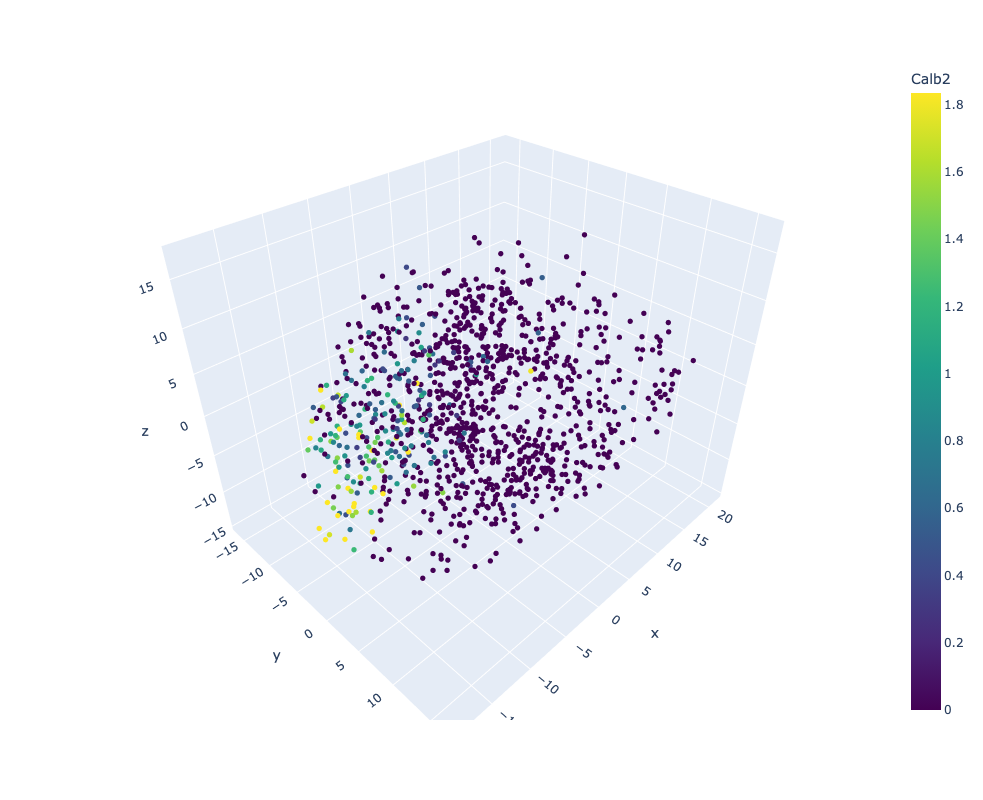

In [63]:
import plotly.express as px

gn = 'Calb2'
vmin = np.percentile(df[gn],  2)
vmax = np.percentile(df[gn], 98)

fig = px.scatter_3d(df, x='x', y='y', z='z',
                    color=gn, 
                    color_continuous_scale='viridis', 
                    range_color=[vmin, vmax],
                   ) 

fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


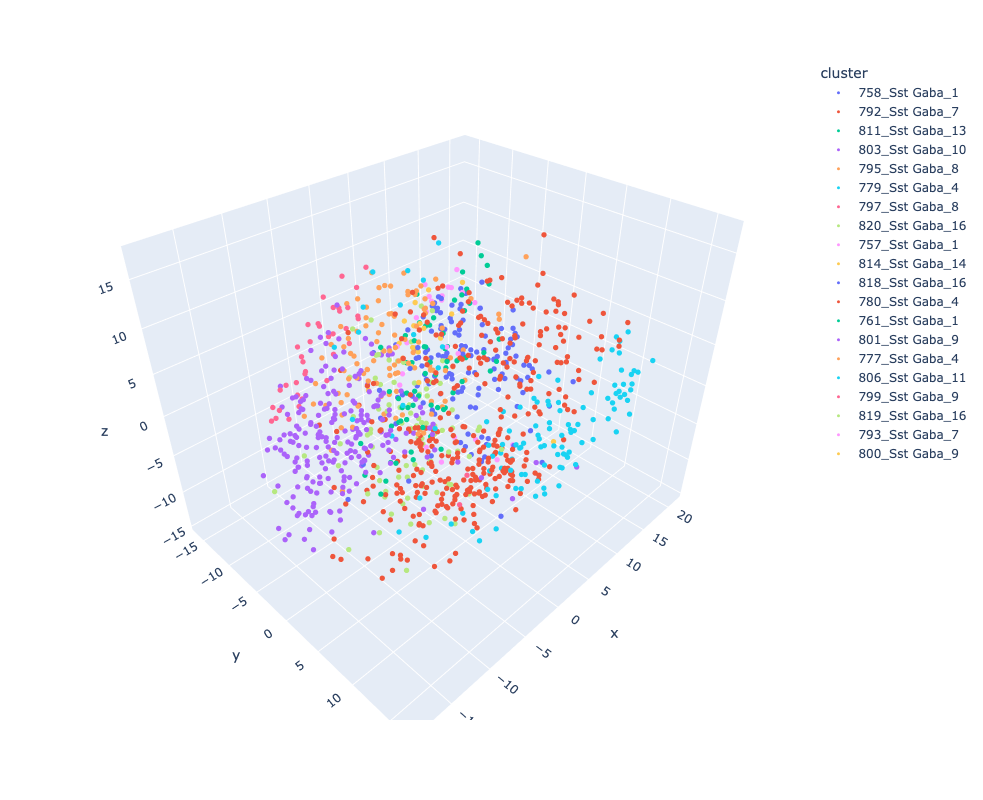

In [64]:



fig = px.scatter_3d(df, x='x', y='y', z='z',
                    color='cluster', 
                    # color_continuous_scale='viridis', 
                    # range_color=[vmin, vmax],
                   ) 

fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)
fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()

In [83]:
df_aa2 = pd.DataFrame(aa2.T)
df_aa2
aa2

array([[-15.48648978,  -1.89494088,   9.5919199 ,  20.32997701],
       [ -4.98144456,   6.565784  ,  14.86512493, -16.29203315],
       [  3.1677033 , -14.06241366,  11.79539661,   2.0597828 ]])

In [87]:
x

array([-15.48648978,  -1.89494088,   9.5919199 ,  20.32997701])

In [92]:
# 1. Define your points (Nodes)
x = aa2[0]
y = aa2[1]
z = aa2[2]

pairs = [(0, 1), 
         (0, 2),
         (0, 3),
         (1, 2),
         (1, 3),
         (2, 3),
        ]

x_lines, y_lines, z_lines = [], [], []

for start_idx, end_idx in pairs:
    # Add start point coordinates
    x_lines.extend([x[start_idx], x[end_idx], None])
    y_lines.extend([y[start_idx], y[end_idx], None])
    z_lines.extend([z[start_idx], z[end_idx], None])

In [97]:
import plotly.graph_objects as go


# 2. Create the initial figure
fig = go.Figure(data=[go.Scatter3d(
    x=df['x'], y=df['y'], z=df['z'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['Calb2'],      # Initial color
        colorscale='Viridis',
        colorbar=dict(title="Value")
    )
)])

# Add archetypes
fig.add_trace(go.Scatter3d(x=x, y=y, z=z,
    mode='markers+lines',
    marker=dict(size=8, color='black', opacity=0.9, symbol='diamond')
))
fig.add_trace(go.Scatter3d(
    x=x_lines, y=y_lines, z=z_lines,
    mode='lines',
    line=dict(color='gray', width=2),
    hoverinfo='none'
))

# 3. Add the Dropdown Menu
fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=gn,
                    method="restyle",
                    args=[{"marker.color": [df[gn]], 
                           "marker.cmin": np.percentile(df[gn],  5),
                           "marker.cmax": np.percentile(df[gn], 95),
                          }] # Note: data must be in a list
                ) for gn in gns
            ],
            direction="down",
            showactive=True,
            x=0.1, y=1.15
        )
    ]
)

fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


In [100]:
import plotly.graph_objects as go


# 2. Create the initial figure
fig = go.Figure(data=[go.Scatter3d(
    x=df['x'], y=df['y'], z=df['z'],
    mode='markers',
    marker=dict(
        size=3,
        color='gray',
    )
)])

# Add archetypes
fig.add_trace(go.Scatter3d(x=x, y=y, z=z,
    mode='markers+lines',
    marker=dict(size=8, color='black', opacity=0.9, symbol='diamond')
))
fig.add_trace(go.Scatter3d(
    x=x_lines, y=y_lines, z=z_lines,
    mode='lines',
    line=dict(color='black', width=4),
    hoverinfo='none'
))

# 3. Add the Dropdown Menu
fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label=gn,
                    method="restyle",
                    args=[{"marker.color": [df[gn]], 
                           "marker.cmin": np.percentile(df[gn],  5),
                           "marker.cmax": np.percentile(df[gn], 95),
                          }] # Note: data must be in a list
                ) for gn in gns
            ],
            direction="down",
            showactive=True,
            x=0.1, y=1.15
        )
    ]
)

fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()
